# Predicting Antimicrobial Resistance Patterns in Kazakhstan Using Zero-Shot Machine Learning

This notebook implements a zero-shot machine learning framework to predict antimicrobial resistance (AMR) patterns in Kazakhstan using three global clinical surveillance databases enriched with macroeconomic indicators.

**Key design:** Kazakhstan is fully excluded from model training. The model generalizes to Kazakhstan using macroeconomic proxy features (GDP, health expenditure, population density), enabling zero-shot prediction in the absence of local clinical training data.

---

## Dataset Sources (Public Kaggle Datasets)

| Dataset | Description | Kaggle Path |
|---|---|---|
| ATLAS | Global AMR surveillance (Pfizer) | `/kaggle/input/atlas-csv/atlas.csv` |
| SIDERO-WT | Global AMR surveillance (Shionogi) | `/kaggle/input/ddddddd/sidero_wt.xlsx` |
| KEYSTONE | Global AMR surveillance | `/kaggle/input/ddddddd/keystone.xlsx` |
| World Bank Macro (Global) | GDP, health expenditure, population density | `/kaggle/input/datasets/uaisamangeldi/macrob/` |
| World Bank Macro (Kazakhstan) | Kazakhstan-specific macro indicators | `/kaggle/input/datasets/uaisamangeldi/macro-kz/` |
| Kazakhstan DID | Antibiotic consumption DDD per 1000/day (2017–2023) | `/kaggle/input/datasets/uaisamangeldi/kz-data/kazakhstan_antibiotics_did_2017_2023.csv` |

> ATLAS, SIDERO-WT, and KEYSTONE were obtained via formal data request through [vivli.org](https://vivli.org).
> World Bank indicators used: NY.GDP.PCAP.CD · SH.XPD.CHEX.GD.ZS · EN.POP.DNST

---

## Notebook Structure
1. Setup & Dependencies
2. Data Loading & Harmonization
3. Leakage Audit
4. Global Macroeconomic Feature Engineering
5. Feature Set Definition
6. Domain Split
7. Model Training (RF · XGBoost · LightGBM)
8. LOCO Validation
9. 5-Fold Time-Aware Cross-Validation
10. Kazakhstan Macroeconomic Data Processing
11. Zero-Shot Prediction for Kazakhstan
12. Results & Visualization


## 1. Setup & Dependencies

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
os.makedirs('/kaggle/working/', exist_ok=True)
print("Environment ready.")

Environment ready.


## 2. Data Loading & Harmonization

Three global AMR surveillance databases are loaded, standardized, and merged into a single unified dataset.

**Resistance encoding:**
- SIR: R=1, S=0, I=discarded (clinically ambiguous)
- MIC: binary via simplified CLSI/EUCAST breakpoints
- Unique isolate IDs: `{SOURCE}_{original_id}_{year}` to prevent cross-database collisions


In [2]:
ATLAS_PATH    = '/kaggle/input/datasets/uaisamangeldi/atlas-csv/atlas.csv'
SIDERO_PATH   = '/kaggle/input/datasets/uaisamangeldi/ddddddd/sidero_wt.xlsx'
KEYSTONE_PATH = '/kaggle/input/datasets/uaisamangeldi/ddddddd/keystone.xlsx'
COMBINED_OUTPUT = '/kaggle/working/combined_dataset.csv'

def parse_sir_to_binary(sir_str):
    """SIR → binary. Intermediate (I) discarded as clinically ambiguous."""
    if pd.isna(sir_str):
        return np.nan
    s = str(sir_str).strip().upper()
    if s in ['R', 'RESISTANT']:   return 1
    if s in ['S', 'SUSCEPTIBLE']: return 0
    return np.nan

def clean_mic_value(val):
    """Normalize MIC string to float."""
    if pd.isna(val): return np.nan
    val = str(val).strip().replace(',', '.')
    for sym in ['<=', '≤', '>=', '≥']:
        val = val.replace(sym, '')
    if '>' in val:
        try: return float(val.replace('>', '').strip()) + 0.0001
        except: return np.nan
    try: return float(val.strip())
    except: return np.nan

def parse_mic_to_binary(mic_val, antibiotic):
    """MIC → binary using simplified CLSI/EUCAST breakpoints."""
    mic = clean_mic_value(mic_val)
    if pd.isna(mic): return np.nan
    thresholds = {
        'Meropenem': 4, 'Imipenem': 4, 'Ceftazidime': 8,
        'Ciprofloxacin': 1, 'Colistin': 4, 'Amikacin': 16,
        'Gentamicin': 8, 'Cefepime': 8,
    }
    return 1 if mic > thresholds.get(antibiotic, 8) else 0

def assign_unique_isolate_id(df, data_source):
    """Composite isolate ID: {source}_{original_id}_{year} — prevents cross-database collisions."""
    if data_source == 'ATLAS' and 'Isolate Id' in df.columns:
        df['original_id'] = df['Isolate Id'].astype(str).str.strip()
    elif data_source == 'KEYSTONE' and 'Collection Number' in df.columns:
        df['original_id'] = df['Collection Number'].astype(str).str.strip()
    else:
        df['original_id'] = df.index.astype(str)
    df['isolate_id'] = data_source + '_' + df['original_id'] + '_' + df['year'].fillna(0).astype(int).astype(str)
    return df

def process_dataset(path, data_source, chunksize=250000):
    print(f"Processing {data_source}...")
    is_csv = path.endswith('.csv')
    reader = pd.read_csv if is_csv else pd.read_excel
    chunks = reader(path, chunksize=chunksize, low_memory=False) if is_csv else [reader(path)]
    processed = []

    for i, chunk in enumerate(chunks):
        print(f"  Chunk {i+1}: {len(chunk)} rows")
        rename = {
            'Isolate Id': 'original_id_temp', 'Species': 'organism',
            'Country': 'country', 'Year': 'year',
            'Organism Name': 'organism', 'Year Collected': 'year',
            'Organism': 'organism', 'Study Year': 'year',
            'Collection Number': 'original_id_temp',
        }
        chunk = chunk.rename(columns=rename)
        for col in ['country', 'year', 'organism']:
            if col not in chunk.columns:
                chunk[col] = 'Unknown' if col != 'year' else np.nan
        chunk['country']  = chunk['country'].astype(str).str.strip()
        chunk['organism'] = chunk['organism'].astype(str).str.strip()
        chunk['year']     = pd.to_numeric(chunk['year'], errors='coerce').astype('Int16')
        chunk = assign_unique_isolate_id(chunk, data_source)

        sir_cols = [c for c in chunk.columns if c.endswith('_I')]
        mic_cols = [c for c in chunk.columns if c not in
                    sir_cols + ['isolate_id', 'country', 'year', 'organism', 'original_id', 'original_id_temp']]
        value_vars   = sir_cols if sir_cols else mic_cols
        melt_varname = 'antibiotic_raw' if sir_cols else 'antibiotic'
        if not value_vars: continue

        long = pd.melt(chunk, id_vars=['isolate_id', 'country', 'year', 'organism'],
                       value_vars=value_vars, var_name=melt_varname, value_name='test_result')

        if sir_cols:
            long['antibiotic'] = long['antibiotic_raw'].str.replace('_I$', '', regex=True).str.strip()
            long['resistance']  = long['test_result'].apply(parse_sir_to_binary)
        else:
            long['antibiotic'] = long['antibiotic'].str.strip()
            long['resistance']  = long.apply(lambda r: parse_mic_to_binary(r['test_result'], r['antibiotic']), axis=1)

        long = long.dropna(subset=['resistance'])
        long['resistance']   = long['resistance'].astype('int8')
        long['data_source']  = data_source
        processed.append(long)

    result = pd.concat(processed, ignore_index=True)
    print(f"  → {len(result):,} rows")
    return result

atlas    = process_dataset(ATLAS_PATH,    'ATLAS')
sidero   = process_dataset(SIDERO_PATH,   'SIDERO-WT')
keystone = process_dataset(KEYSTONE_PATH, 'KEYSTONE')

combined = pd.concat([atlas, sidero, keystone], ignore_index=True)
combined.to_csv(COMBINED_OUTPUT, index=False)
print(f"\nCombined: {len(combined):,} rows | {combined['isolate_id'].nunique():,} unique isolates")
print(f"Class distribution:\n{combined['resistance'].value_counts(normalize=True).round(4)}")

Processing ATLAS...
  Chunk 1: 250000 rows
  Chunk 2: 250000 rows
  Chunk 3: 250000 rows
  Chunk 4: 216805 rows
  → 10,717,988 rows
Processing SIDERO-WT...
  Chunk 1: 47615 rows
  → 435,633 rows
Processing KEYSTONE...
  Chunk 1: 90208 rows
  → 1,296,305 rows

Combined: 12,449,926 rows | 1,100,391 unique isolates
Class distribution:
resistance
0    0.8036
1    0.1964
Name: proportion, dtype: float64


## 3. Leakage Audit

Temporal split: Train ≤ 2020, Validation 2021–2022, Test > 2022.
Explicit audit confirms zero isolate ID overlap across all three partitions.


In [3]:
full_df = pd.read_csv('/kaggle/working/combined_dataset.csv', low_memory=False)
full_df_sorted = full_df.sort_values('year').reset_index(drop=True)

TRAIN_CUTOFF, VAL_CUTOFF = 2020, 2022

train = full_df_sorted[full_df_sorted['year'] <= TRAIN_CUTOFF]
val   = full_df_sorted[(full_df_sorted['year'] > TRAIN_CUTOFF) & (full_df_sorted['year'] <= VAL_CUTOFF)]
test  = full_df_sorted[full_df_sorted['year'] > VAL_CUTOFF]

print(f"Train : {len(train):,} rows (≤ {TRAIN_CUTOFF})")
print(f"Val   : {len(val):,} rows ({TRAIN_CUTOFF+1}–{VAL_CUTOFF})")
print(f"Test  : {len(test):,} rows (> {VAL_CUTOFF})")

train_ids, val_ids, test_ids = set(train['isolate_id']), set(val['isolate_id']), set(test['isolate_id'])
print(f"\nTrain-Val overlap  : {len(train_ids & val_ids):,}")
print(f"Train-Test overlap : {len(train_ids & test_ids):,}")
print(f"Val-Test overlap   : {len(val_ids & test_ids):,}")
print("\nLeakage audit PASSED." if len(train_ids & test_ids) == 0 else "\nWARNING: Leakage detected.")

Train : 9,755,320 rows (≤ 2020)
Val   : 1,892,959 rows (2021–2022)
Test  : 801,647 rows (> 2022)

Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0

Leakage audit PASSED.


## 4. Global Macroeconomic Feature Engineering

World Bank indicators (GDP per capita, health expenditure % GDP, population density) and global antibiotic consumption (DDD/1000/day) are merged into the global dataset by country and year.

Missing values are imputed using forward fill then backward fill within each country group, with the global column mean applied as a fallback for countries with no data across any year.

Log transformations are applied to GDP per capita and antibiotic consumption to reduce right-skew.


In [4]:
POP_DENSITY_PATH = '/kaggle/input/datasets/uaisamangeldi/macrob/API_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv'
GDP_PCAP_PATH    = '/kaggle/input/datasets/uaisamangeldi/macrob/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv'
HEALTH_GDP_PATH  = '/kaggle/input/datasets/uaisamangeldi/macrob/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_938/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_938.csv'
CONSUMPTION_PATH = '/kaggle/input/datasets/uaisamangeldi/consumption/antibiotic-consumption-rate.csv'

def wb_long_format(path, value_col_name):
    """Parse World Bank CSV (wide) to long format keyed by country and year."""
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path, skiprows=4, low_memory=False)
    df.columns = df.columns.str.strip()
    if 'Country Name' not in df.columns:
        print(f"'Country Name' missing in {path}")
        return pd.DataFrame()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df_long = pd.melt(df, id_vars=['Country Name'], value_vars=year_cols,
                      var_name='year', value_name=value_col_name)
    df_long['year'] = df_long['year'].astype(int)
    df_long = df_long.rename(columns={'Country Name': 'country'})
    df_long[value_col_name] = pd.to_numeric(df_long[value_col_name], errors='coerce')
    result = df_long[['country', 'year', value_col_name]].dropna(subset=[value_col_name])
    print(f"  {value_col_name}: {len(result):,} rows, {result['country'].nunique()} countries")
    return result

df_pop    = wb_long_format(POP_DENSITY_PATH, 'population_density_per_sq_km')
df_gdp    = wb_long_format(GDP_PCAP_PATH,    'gdp_per_capita_usd')
df_health = wb_long_format(HEALTH_GDP_PATH,  'health_expenditure_pct_gdp')

macro_df = df_gdp.copy()
for df in [df_pop, df_health]:
    macro_df = macro_df.merge(df, on=['country', 'year'], how='outer')

COUNTRY_MAP = {
    'United States': 'USA', 'United States of America': 'USA',
    'Russian Federation': 'Russia', 'Korea, Rep.': 'South Korea',
}
macro_df['country'] = macro_df['country'].replace(COUNTRY_MAP)
full_df['country']  = full_df['country'].replace(COUNTRY_MAP)

macro_cols_to_drop = [
    'gdp_per_capita_usd', 'population_density_per_sq_km', 'health_expenditure_pct_gdp',
    'consumption_ddd_per_1000_day', 'log_gdp_per_capita', 'log_consumption_ddd',
]
full_df = full_df.drop(columns=[c for c in macro_cols_to_drop if c in full_df.columns])

full_df = full_df.merge(macro_df, on=['country', 'year'], how='left')

df_cons = pd.read_csv(CONSUMPTION_PATH)
df_cons = df_cons.rename(columns={
    'Entity': 'country', 'Year': 'year',
    'Defined daily doses of antibiotics and antituberculosis drugs used per 1,000 inhabitants per day': 'consumption_ddd_per_1000_day'
})
df_cons = df_cons[['country', 'year', 'consumption_ddd_per_1000_day']]
df_cons['country'] = df_cons['country'].replace({'Russian Federation': 'Russia', 'United States': 'USA'})
full_df = full_df.merge(df_cons, on=['country', 'year'], how='left')

fill_cols = ['gdp_per_capita_usd', 'population_density_per_sq_km',
             'health_expenditure_pct_gdp', 'consumption_ddd_per_1000_day']
for col in fill_cols:
    if col in full_df.columns:
        full_df[col] = full_df.groupby('country')[col].transform(lambda x: x.ffill().bfill())
        full_df[col] = full_df[col].fillna(full_df[col].mean())

full_df['log_gdp_per_capita']  = np.log1p(full_df['gdp_per_capita_usd'])
full_df['log_consumption_ddd'] = np.log1p(full_df['consumption_ddd_per_1000_day'].clip(lower=0))

full_df.to_csv('/kaggle/working/full_amr_with_macro.csv', index=False)
print(f"\nSaved: full_amr_with_macro.csv | Shape: {full_df.shape}")
print(f"\nMacro coverage (non-null %):")
print((full_df[fill_cols].notna().mean() * 100).round(1))

  population_density_per_sq_km: 6,217 rows, 264 countries
  gdp_per_capita_usd: 6,433 rows, 262 countries
  health_expenditure_pct_gdp: 5,716 rows, 241 countries

Saved: full_amr_with_macro.csv | Shape: (12449926, 15)

Macro coverage (non-null %):
gdp_per_capita_usd              100.0
population_density_per_sq_km    100.0
health_expenditure_pct_gdp      100.0
consumption_ddd_per_1000_day    100.0
dtype: float64


## 5. Feature Set Definition

Country name is deliberately excluded to enable zero-shot generalization.
The model characterizes each country purely through its macroeconomic profile.

Feature set matches the final validated pipeline from the original notebook.


In [5]:
CAT_FEATURES = ['organism', 'antibiotic']

NUM_FEATURES = [
    'year',
    'gdp_per_capita_usd',
    'health_expenditure_pct_gdp',
    'population_density_per_sq_km',
]

FEATURES = CAT_FEATURES + NUM_FEATURES

print("Categorical features :", CAT_FEATURES)
print("Numerical features   :", NUM_FEATURES)
print("Total features       :", len(FEATURES))
print("\nNote: 'country' excluded — zero-shot design requires country-agnostic features.")
print("Note: 'data_source' excluded — would leak database identity into predictions.")

Categorical features : ['organism', 'antibiotic']
Numerical features   : ['year', 'gdp_per_capita_usd', 'health_expenditure_pct_gdp', 'population_density_per_sq_km']
Total features       : 6

Note: 'country' excluded — zero-shot design requires country-agnostic features.
Note: 'data_source' excluded — would leak database identity into predictions.


## 6. Domain Split

Kazakhstan is excluded from the source (training) domain entirely.
Proxy countries are used for LOCO validation as surrogates for Kazakhstan.


In [6]:
full_df = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
full_df = full_df.loc[:, ~full_df.columns.duplicated()]

PROXY_COUNTRIES = ['Russia', 'Turkey', 'Mexico', 'Belarus', 'Ukraine', 'Bulgaria']

required_cols = ['isolate_id', 'country', 'year', 'resistance'] + FEATURES

source_df = full_df[~full_df['country'].isin(['Kazakhstan'])][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

print(f"Source domain: {len(source_df):,} rows | {source_df['country'].nunique()} countries")
print(f"\nClass distribution:")
print(source_df['resistance'].value_counts(normalize=True).round(4))

POS_WEIGHT = (source_df['resistance'] == 0).sum() / (source_df['resistance'] == 1).sum()
print(f"\nscale_pos_weight = {POS_WEIGHT:.2f}")

Source domain: 12,449,926 rows | 85 countries

Class distribution:
resistance
0    0.8036
1    0.1964
Name: proportion, dtype: float64

scale_pos_weight = 4.09


## 7. Model Training

Three models trained on identical feature sets and temporal splits:
- **Random Forest** — baseline (class_weight='balanced')
- **XGBoost** — GPU-accelerated, histogram method (scale_pos_weight)
- **LightGBM** — GPU-accelerated, leaf-wise growth (scale_pos_weight, early stopping)

Temporal split: Train ≤ 2020 | Validation 2021–2022.
Label encoding fit on training data only — validation labels mapped, unknowns assigned -1.


In [13]:
source_sorted = source_df.sort_values('year').reset_index(drop=True)
train_df = source_sorted[source_sorted['year'] <= 2020].copy()
val_df   = source_sorted[(source_sorted['year'] > 2020) & (source_sorted['year'] <= 2022)].copy()

print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")

label_encoders = {}
X_train = train_df[FEATURES].copy()
X_val   = val_df[FEATURES].copy()
y_train = train_df['resistance']
y_val   = val_df['resistance']

for col in CAT_FEATURES:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_val[col] = X_val[col].fillna('unknown').astype(str).map(lambda s, d=le_dict: d.get(s, -1))
    label_encoders[col] = le

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\nTraining Random Forest (baseline)...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict_proba(X_val)[:, 1]
print(f"Random Forest — AUC: {roc_auc_score(y_val, y_pred_rf):.4f} | AUPRC: {average_precision_score(y_val, y_pred_rf):.4f}")

print("\nTraining XGBoost...")
xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': ['auc', 'aucpr'],
    'max_depth': 7,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'scale_pos_weight': pos_weight,
    'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1,
}
try:
    import cupy
    xgb_params['device'] = 'cuda'
    print("XGBoost → GPU")
except ImportError:
    xgb_params['device'] = 'cpu'
    print("XGBoost → CPU")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)
model_xgb = xgb.train(
    xgb_params, dtrain,
    num_boost_round=3000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=200
)
y_pred_xgb = model_xgb.predict(dval)
print(f"XGBoost — AUC: {roc_auc_score(y_val, y_pred_xgb):.4f} | AUPRC: {average_precision_score(y_val, y_pred_xgb):.4f}")
print(f"XGBoost best round: {model_xgb.best_iteration}")

print("\nTraining LightGBM...")
lgb_params = {
    'objective': 'binary', 'metric': ['auc', 'aucpr'],
    'learning_rate': 0.03,
    'max_depth': 7,
    'num_leaves': 63,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 50,
    'scale_pos_weight': pos_weight,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1,
}
try:
    import pyopencl
    lgb_params['device'] = 'gpu'
    print("LightGBM → GPU")
except ImportError:
    lgb_params['device'] = 'cpu'
    print("LightGBM → CPU")

train_lgb = lgb.Dataset(X_train, label=y_train)
val_lgb   = lgb.Dataset(X_val,   label=y_val, reference=train_lgb)
model_lgb = lgb.train(
    lgb_params, train_lgb,
    num_boost_round=3000,
    valid_sets=[train_lgb, val_lgb], valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(200)
    ]
)
y_pred_lgb = model_lgb.predict(X_val)
print(f"LightGBM — AUC: {roc_auc_score(y_val, y_pred_lgb):.4f} | AUPRC: {average_precision_score(y_val, y_pred_lgb):.4f}")
print(f"LightGBM best round: {model_lgb.best_iteration}")

print("\n--- Classification Report (LightGBM — best model) ---")
print(classification_report(y_val, (y_pred_lgb > 0.5).astype(int),
                             target_names=['Susceptible', 'Resistant']))

model_xgb.save_model('/kaggle/working/xgboost_model.json')
model_lgb.save_model('/kaggle/working/lightgbm_model.txt')
with open('/kaggle/working/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Models saved.")

Train: 9,755,320 | Val: 1,892,959

Training Random Forest (baseline)...
Random Forest — AUC: 0.8518 | AUPRC: 0.6107

Training XGBoost...
XGBoost → GPU
[0]	train-auc:0.68222	train-aucpr:0.37189	val-auc:0.69767	val-aucpr:0.42307
[175]	train-auc:0.88225	train-aucpr:0.67367	val-auc:0.83497	val-aucpr:0.52063
XGBoost — AUC: 0.8350 | AUPRC: 0.5208
XGBoost best round: 75

Training LightGBM...
LightGBM → CPU
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.88781	val's auc: 0.84216
[400]	train's auc: 0.900488	val's auc: 0.853269
[600]	train's auc: 0.905974	val's auc: 0.860086
[800]	train's auc: 0.90861	val's auc: 0.863317
[1000]	train's auc: 0.910542	val's auc: 0.86518
[1200]	train's auc: 0.911956	val's auc: 0.866742
[1400]	train's auc: 0.912846	val's auc: 0.866847
Early stopping, best iteration is:
[1304]	train's auc: 0.912455	val's auc: 0.867311
LightGBM — AUC: 0.8673 | AUPRC: 0.5816
LightGBM best round: 1304

--- Classification Report (LightGBM — best model) 

## 8. LOCO Validation (Leave-One-Country-Out)

Model trained on all countries except a target proxy country, evaluated on that country.
Russia is the primary proxy for Kazakhstan. LOCO results quantify zero-shot generalization.
Label encoding fit on training fold only — test labels mapped with -1 fallback.


In [8]:
source_df = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
source_df = source_df[~source_df['country'].isin(['Kazakhstan'])][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

loco_results = []

for test_country in PROXY_COUNTRIES:
    train_loco = source_df[source_df['country'] != test_country].copy()
    test_loco  = source_df[source_df['country'] == test_country].copy()

    if len(test_loco) < 200:
        continue

    X_tr = train_loco[FEATURES].copy()
    X_te = test_loco[FEATURES].copy()
    y_tr = train_loco['resistance']
    y_te = test_loco['resistance']

    for col in CAT_FEATURES:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].fillna('unknown').astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_te[col] = X_te[col].fillna('unknown').astype(str).map(lambda s, d=le_dict: d.get(s, -1))

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    model = LGBMClassifier(n_estimators=800, learning_rate=0.05, max_depth=6,
                           num_leaves=32, scale_pos_weight=spw, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te, y_prob) if y_te.nunique() > 1 else np.nan
    auprc = average_precision_score(y_te, y_prob) if y_te.nunique() > 1 else np.nan

    loco_results.append({'country': test_country, 'n_test': len(test_loco), 'AUC': auc, 'AUPRC': auprc})
    print(f"LOCO {test_country:12s} — AUC: {auc:.4f} | AUPRC: {auprc:.4f}")

loco_df = pd.DataFrame(loco_results)
print(f"\nMean LOCO AUC  : {loco_df['AUC'].mean():.4f}")
print(f"Mean LOCO AUPRC: {loco_df['AUPRC'].mean():.4f}")
loco_df.to_csv('/kaggle/working/loco_results.csv', index=False)

LOCO Russia       — AUC: 0.8793 | AUPRC: 0.7398
LOCO Turkey       — AUC: 0.8721 | AUPRC: 0.7423
LOCO Mexico       — AUC: 0.8576 | AUPRC: 0.6938
LOCO Belarus      — AUC: 0.8641 | AUPRC: 0.6421
LOCO Ukraine      — AUC: 0.8687 | AUPRC: 0.8172
LOCO Bulgaria     — AUC: 0.8750 | AUPRC: 0.7894

Mean LOCO AUC  : 0.8695
Mean LOCO AUPRC: 0.7374


## 9. 5-Fold Time-Aware Cross-Validation

Folds constructed chronologically by year quantiles.
Isolate ID group constraints prevent the same isolate appearing in both train and validation within any fold.


In [14]:
source_df = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
source_df = source_df[~source_df['country'].isin(['Kazakhstan'])][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]
source_df = source_df.sort_values('year').reset_index(drop=True)

groups = source_df['isolate_id']

years = sorted(source_df['year'].unique())
n_years = len(years)

segment_size = n_years // 6
fold_boundaries = [
    (years[0],                          years[min((i+1)*segment_size - 1, n_years-1)],
     years[min((i+1)*segment_size, n_years-1)], years[min((i+2)*segment_size - 1, n_years-1)])
    for i in range(5)
]

print("Fold year boundaries:")
for i, (tr_start, tr_end, vl_start, vl_end) in enumerate(fold_boundaries):
    print(f"  Fold {i+1}: Train {tr_start}–{tr_end} | Val {vl_start}–{vl_end}")

N_SPLITS = 5
fold_metrics = []

for fold, (tr_start, tr_end, vl_start, vl_end) in enumerate(fold_boundaries):
    train_mask = (source_df['year'] >= tr_start) & (source_df['year'] <= tr_end)
    val_mask   = (source_df['year'] >= vl_start) & (source_df['year'] <= vl_end)

    train_isolates = set(groups[train_mask])
    val_isolates   = set(groups[val_mask])
    overlapping    = train_isolates & val_isolates
    train_mask     = train_mask & ~groups.isin(overlapping)

    X_tr_raw = source_df.loc[train_mask, FEATURES].copy()
    X_vl_raw = source_df.loc[val_mask,   FEATURES].copy()
    y_tr = source_df.loc[train_mask, 'resistance']
    y_vl = source_df.loc[val_mask,   'resistance']

    if len(X_vl_raw) < 1000 or y_vl.nunique() < 2:
        print(f"Fold {fold+1}: skipped (insufficient data)")
        continue

    X_tr = X_tr_raw.copy()
    X_vl = X_vl_raw.copy()
    for col in CAT_FEATURES:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].fillna('unknown').astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_vl[col] = X_vl[col].fillna('unknown').astype(str).map(
            lambda s, d=le_dict: d.get(s, -1)
        )

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    model = LGBMClassifier(
        n_estimators=1000, learning_rate=0.05, max_depth=6,
        num_leaves=32, scale_pos_weight=spw, random_state=42, verbose=-1
    )
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_vl)[:, 1]
    auc   = roc_auc_score(y_vl, y_prob)
    auprc = average_precision_score(y_vl, y_prob)
    fold_metrics.append({'fold': fold + 1, 'train_years': f"{tr_start}–{tr_end}",
                         'val_years': f"{vl_start}–{vl_end}",
                         'train_size': len(X_tr), 'val_size': len(X_vl),
                         'AUC': auc, 'AUPRC': auprc})
    print(f"Fold {fold+1} — Train {tr_start}–{tr_end} | Val {vl_start}–{vl_end} | "
          f"AUC: {auc:.4f} | AUPRC: {auprc:.4f}")

cv_df = pd.DataFrame(fold_metrics)
print(f"\nMean CV AUC  : {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")
print(f"Mean CV AUPRC: {cv_df['AUPRC'].mean():.4f} ± {cv_df['AUPRC'].std():.4f}")
print(cv_df[['fold', 'train_years', 'val_years', 'train_size', 'val_size', 'AUC', 'AUPRC']].to_string(index=False))

Fold year boundaries:
  Fold 1: Train 2004–2006 | Val 2007–2009
  Fold 2: Train 2004–2009 | Val 2010–2012
  Fold 3: Train 2004–2012 | Val 2013–2015
  Fold 4: Train 2004–2015 | Val 2016–2018
  Fold 5: Train 2004–2018 | Val 2019–2021
Fold 1 — Train 2004–2006 | Val 2007–2009 | AUC: 0.8950 | AUPRC: 0.7369
Fold 2 — Train 2004–2009 | Val 2010–2012 | AUC: 0.8686 | AUPRC: 0.6728
Fold 3 — Train 2004–2012 | Val 2013–2015 | AUC: 0.8742 | AUPRC: 0.6654
Fold 4 — Train 2004–2015 | Val 2016–2018 | AUC: 0.8728 | AUPRC: 0.6580
Fold 5 — Train 2004–2018 | Val 2019–2021 | AUC: 0.8612 | AUPRC: 0.5753

Mean CV AUC  : 0.8744 ± 0.0126
Mean CV AUPRC: 0.6617 ± 0.0576
 fold train_years val_years  train_size  val_size      AUC    AUPRC
    1   2004–2006 2007–2009      582250    945615 0.895040 0.736874
    2   2004–2009 2010–2012     1527865   1024457 0.868638 0.672830
    3   2004–2012 2013–2015     2552322   2382616 0.874194 0.665407
    4   2004–2015 2016–2018     4934938   2999479 0.872788 0.657994
    5   20

## 10. Kazakhstan Macroeconomic Data Processing

Kazakhstan-specific antibiotic consumption (DID per 1000/day, 2017–2023) merged with Kazakhstan World Bank macro indicators.
This dataset is used **exclusively for zero-shot inference** — never seen during model training.


In [10]:
KZ_MACRO_FILES = {
    'gdp_per_capita_usd':         '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv',
    'health_expenditure_pct_gdp': '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv',
    'population_total':           '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_SP.POP.TOTL_DS2_en_csv_v2_61/API_SP.POP.TOTL_DS2_en_csv_v2_61.csv',
}
KZ_DID_PATH = '/kaggle/input/datasets/uaisamangeldi/kz-data/kazakhstan_antibiotics_did_2017_2023.csv'
KZ_AREA_KM2 = 2_724_900

def load_kz_wb_indicator(path, col_name):
    """Load a single World Bank indicator for Kazakhstan only."""
    df = pd.read_csv(path, skiprows=4)
    df.columns = df.columns.str.strip()
    df = df[df['Country Name'] == 'Kazakhstan'].copy()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df = df.melt(id_vars=['Country Name'], value_vars=year_cols, var_name='year', value_name=col_name)
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year', col_name])
    df['year'] = df['year'].astype(int)
    return df[['year', col_name]]

kz_macro = load_kz_wb_indicator(KZ_MACRO_FILES['gdp_per_capita_usd'], 'gdp_per_capita_usd')
for col, path in list(KZ_MACRO_FILES.items())[1:]:
    kz_macro = kz_macro.merge(load_kz_wb_indicator(path, col), on='year', how='outer')

kz_macro = kz_macro.sort_values('year').reset_index(drop=True)
kz_macro['population_density_per_sq_km'] = kz_macro['population_total'] / KZ_AREA_KM2

kz_did = pd.read_csv(KZ_DID_PATH)
kz_did.columns = kz_did.columns.str.strip()
kz_did['antibiotic']     = kz_did['antibiotic'].str.strip().str.lower().str.replace('/', ' / ')
kz_did['aware_category'] = kz_did['aware_category'].fillna('Unknown')
kz_did['did']            = pd.to_numeric(kz_did['did'], errors='coerce').fillna(0)

kz_macro_filtered = kz_macro[(kz_macro['year'] >= 2017) & (kz_macro['year'] <= 2023)]
kz_final = kz_did.merge(kz_macro_filtered, on='year', how='inner')
kz_final = kz_final.sort_values(['year', 'antibiotic']).reset_index(drop=True)
kz_final = kz_final.rename(columns={'did': 'consumption_ddd_per_1000_day'})

kz_final.to_csv('/kaggle/working/kazakhstan_final_prediction_input_2017_2023.csv', index=False)
print(f"Kazakhstan inference dataset: {kz_final.shape}")
print(kz_final[['year', 'antibiotic', 'consumption_ddd_per_1000_day', 'gdp_per_capita_usd']].head(6))

Kazakhstan inference dataset: (183, 9)
   year                     antibiotic  consumption_ddd_per_1000_day  \
0  2017                       amikacin                         0.098   
1  2017                    amoxicillin                         0.040   
2  2017  amoxicillin / clavulanic acid                         0.102   
3  2017                     ampicillin                         0.033   
4  2017                   azithromycin                         0.110   
5  2017               benzylpenicillin                         0.037   

   gdp_per_capita_usd  
0         8943.084168  
1         8943.084168  
2         8943.084168  
3         8943.084168  
4         8943.084168  
5         8943.084168  


## 11. Zero-Shot Prediction for Kazakhstan

Model trained exclusively on non-Kazakh global data, applied to Kazakhstan using macroeconomic proxy features.
A prediction grid crosses Kazakhstan antibiotic-year rows with 6 target pathogen species.

**Encoding:** Fit on source training data only. KZ antibiotic names normalized to lowercase to ensure
vocabulary alignment. Unknown labels mapped to -1.


In [18]:
source_df  = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
kz_base_df = pd.read_csv('/kaggle/working/kazakhstan_final_prediction_input_2017_2023.csv')

source_df = source_df[~source_df['country'].isin(['Kazakhstan'])].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

source_df['antibiotic'] = (source_df['antibiotic']
                           .astype(str).str.strip().str.lower()
                           .str.replace('/', ' / ', regex=False)
                           .str.replace(r'\s+', ' ', regex=True)
                           .str.strip())

TARGET_ORGANISMS = [
    'Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus',
    'Pseudomonas aeruginosa', 'Acinetobacter baumannii', 'Enterococcus faecium'
]

prediction_rows = []
for _, row in kz_base_df.iterrows():
    for org in TARGET_ORGANISMS:
        new_row = row.to_dict()
        new_row['organism'] = org
        prediction_rows.append(new_row)

kz_df = pd.DataFrame(prediction_rows)

kz_df['antibiotic'] = (kz_df['antibiotic']
                       .astype(str)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())

source_antibiotics = set(source_df['antibiotic'].unique())
kz_antibiotics_raw = set(kz_df['antibiotic'].unique())

print("=== ANTIBIOTIC VOCABULARY INVESTIGATION ===")
print(f"Source database unique antibiotics: {len(source_antibiotics)}")
print(f"KZ DID unique antibiotics         : {len(kz_antibiotics_raw)}")

print("\nKZ antibiotic → Source match status:")
for ab in sorted(kz_antibiotics_raw):
    status = "✓ MATCHED" if ab in source_antibiotics else "✗ unmatched"
    print(f"  {status}: '{ab}'")

antibiotic_harmonize = {
    'amoxicillin / clavulanic acid':            'amoxicillin- clavulanic acid',
    'amoxicillin and beta-lactamase inhibitor': 'amoxicillin- clavulanic acid',
    'amoxicillin':                              'amoxycillin clavulanate',
    'imipenem / cilastatin':                    'imipenem',
    'sulfamethoxazole / trimethoprim':          'trimethoprim / sulfamethoxazole',
    'sulfamethoxazole and trimethoprim':        'trimethoprim / sulfamethoxazole',
    'vancomycin (iv)':                          'vancomycin',
    'fosfomycin (iv)':                          'fosfomycin',
    'benzylpenicillin':                         'penicillin',
    'cefpodoxime proxetil':                     'cefpodoxime',
}

kz_df['antibiotic'] = kz_df['antibiotic'].replace(antibiotic_harmonize)

kz_antibiotics_after = set(kz_df['antibiotic'].unique())
matched   = kz_antibiotics_after & source_antibiotics
unmatched = kz_antibiotics_after - source_antibiotics

print(f"\n=== VOCABULARY MATCH AFTER HARMONIZATION ===")
print(f"Matched  : {len(matched)}/{len(kz_antibiotics_after)} ({100*len(matched)/len(kz_antibiotics_after):.1f}%)")
print(f"Matched antibiotics  : {sorted(matched)}")
print(f"\nUnmatched (→ unknown): {sorted(unmatched)}")
print("\nNote: Unmatched antibiotics are regionally specific drugs absent from")
print("ATLAS/SIDERO-WT/KEYSTONE surveillance panels.")

encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    le.fit(source_df[col].fillna('unknown').astype(str))
    source_df[col] = le.transform(source_df[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    kz_df[col] = kz_df[col].fillna('unknown').astype(str).map(
        lambda s, d=le_dict: d.get(s, -1)
    )
    encoders[col] = le

X_source = source_df[FEATURES].copy()
y_source = source_df['resistance'].copy()
valid_mask = X_source.notna().all(axis=1)
X_source   = X_source[valid_mask]
y_source   = y_source[valid_mask]

print(f"\nTraining rows: {len(X_source):,}")
spw = (y_source == 0).sum() / (y_source == 1).sum()
print(f"scale_pos_weight: {spw:.2f}")

try:
    import pyopencl
    lgb_device = 'gpu'
except ImportError:
    lgb_device = 'cpu'

model_final = LGBMClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    scale_pos_weight=spw, importance_type='gain',
    device=lgb_device, random_state=42, verbose=-1
)
model_final.fit(X_source, y_source)
print("Model training complete.")


for col in NUM_FEATURES:
    if col in kz_df.columns:
        kz_df[col] = kz_df[col].fillna(
            source_df[col].mean() if col in source_df.columns else 0
        )

X_kz = kz_df[FEATURES].copy()
print(f"KZ NaN check: {X_kz.isna().sum().sum()} missing values")

kz_df['resistance_prob'] = model_final.predict_proba(X_kz)[:, 1]

for col in CAT_FEATURES:
    le = encoders[col]
    kz_df[col] = kz_df[col].apply(
        lambda x: le.inverse_transform([int(x)])[0] if x != -1 else 'unknown'
    )

top_risks = (
    kz_df.groupby(['organism', 'antibiotic'])['resistance_prob']
    .mean().reset_index()
    .sort_values('resistance_prob', ascending=False)
)

top_risks_matched = top_risks[top_risks['antibiotic'] != 'unknown']
top_risks_unknown = top_risks[top_risks['antibiotic'] == 'unknown']

print(f"\nMatched predictions  : {len(top_risks_matched)}")
print(f"Unknown predictions  : {len(top_risks_unknown)}")

print("\n--- Top 10: Matched Antibiotic Predictions ---")
print(top_risks_matched.head(10).to_string(index=False))

print("\n--- Unknown (driven by organism + macro features only) ---")
print(top_risks_unknown.head(6).to_string(index=False))

kz_df.to_csv('/kaggle/working/kz_zero_shot_predictions.csv', index=False)
top_risks.to_csv('/kaggle/working/kz_top_resistance_risks.csv', index=False)
top_risks_matched.to_csv('/kaggle/working/kz_top_resistance_risks_matched.csv', index=False)
print("\nPredictions saved.")

=== ANTIBIOTIC VOCABULARY INVESTIGATION ===
Source database unique antibiotics: 57
KZ DID unique antibiotics         : 41

KZ antibiotic → Source match status:
  ✓ MATCHED: 'amikacin'
  ✗ unmatched: 'amoxicillin'
  ✗ unmatched: 'amoxicillin / clavulanic acid'
  ✗ unmatched: 'amoxicillin and beta-lactamase inhibitor'
  ✓ MATCHED: 'ampicillin'
  ✓ MATCHED: 'azithromycin'
  ✗ unmatched: 'benzylpenicillin'
  ✗ unmatched: 'cefazolin'
  ✓ MATCHED: 'cefepime'
  ✓ MATCHED: 'cefixime'
  ✗ unmatched: 'cefotaxime'
  ✗ unmatched: 'cefpodoxime proxetil'
  ✓ MATCHED: 'ceftazidime'
  ✓ MATCHED: 'ceftriaxone'
  ✗ unmatched: 'cefuroxime'
  ✗ unmatched: 'chloramphenicol'
  ✓ MATCHED: 'ciprofloxacin'
  ✓ MATCHED: 'clarithromycin'
  ✓ MATCHED: 'doripenem'
  ✓ MATCHED: 'doxycycline'
  ✓ MATCHED: 'ertapenem'
  ✗ unmatched: 'fosfomycin (iv)'
  ✗ unmatched: 'furazidin'
  ✓ MATCHED: 'gentamicin'
  ✗ unmatched: 'imipenem / cilastatin'
  ✗ unmatched: 'kanamycin'
  ✓ MATCHED: 'levofloxacin'
  ✓ MATCHED: 'linezoli

In [17]:

source_df_check = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
source_df_check['antibiotic_normalized'] = (source_df_check['antibiotic']
    .astype(str).str.strip().str.lower()
    .str.replace('/', ' / ', regex=False)
    .str.replace(r'\s+', ' ', regex=True).str.strip())
print(sorted(source_df_check['antibiotic_normalized'].unique()))

['age', 'amikacin', 'amoxicillin- clavulanic acid', 'amoxycillin clavulanate', 'ampicillin', 'ampicillin / sulbactam', 'ampicillin sulbactam', 'azithromycin', 'aztreonam', 'aztreonam / avibactam', 'cefepime', 'cefiderocol', 'cefixime', 'cefoxitin', 'cefpodoxime', 'ceftaroline', 'ceftazidime', 'ceftazidime / avibactam', 'ceftazidime avibactam', 'ceftibuten', 'ceftolozane / tazobactam', 'ceftolozane tazobactam', 'ceftriaxone', 'ciprofloxacin', 'clarithromycin', 'clindamycin', 'colistin', 'daptomycin', 'date collected', 'doripenem', 'doxycycline', 'ertapenem', 'erythromycin', 'gentamicin', 'imipenem', 'imipenem / relebactam', 'levofloxacin', 'linezolid', 'meropenem', 'meropenem / vaborbactam at 8', 'meropenem vaborbactam', 'metronidazole', 'minocycline', 'moxifloxacin', 'omadacycline', 'oxacillin', 'penicillin', 'piperacillin tazobactam', 'piperacillin- tazobactam', 'quinupristin dalfopristin', 'teicoplanin', 'tetracycline', 'tigecycline', 'trimethoprim / sulfamethoxazole', 'trimethoprim 

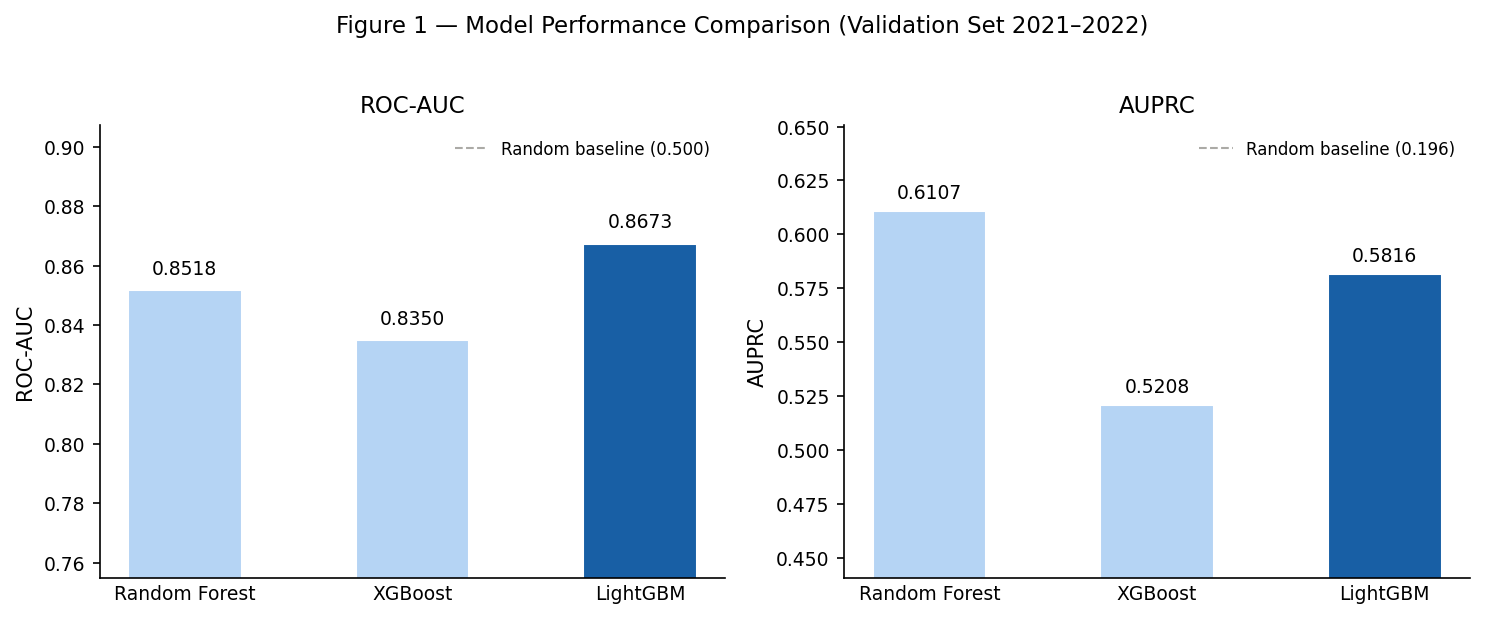

Saved: fig1_model_comparison.png


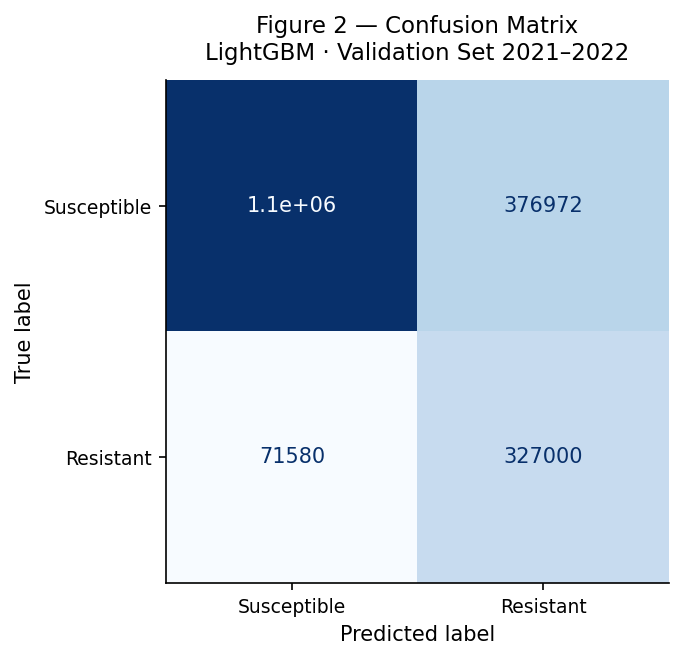

              precision    recall  f1-score   support

 Susceptible     0.9398    0.7477    0.8328   1494379
   Resistant     0.4645    0.8204    0.5932    398580

    accuracy                         0.7630   1892959
   macro avg     0.7022    0.7841    0.7130   1892959
weighted avg     0.8397    0.7630    0.7824   1892959

Saved: fig2_confusion_matrix.png


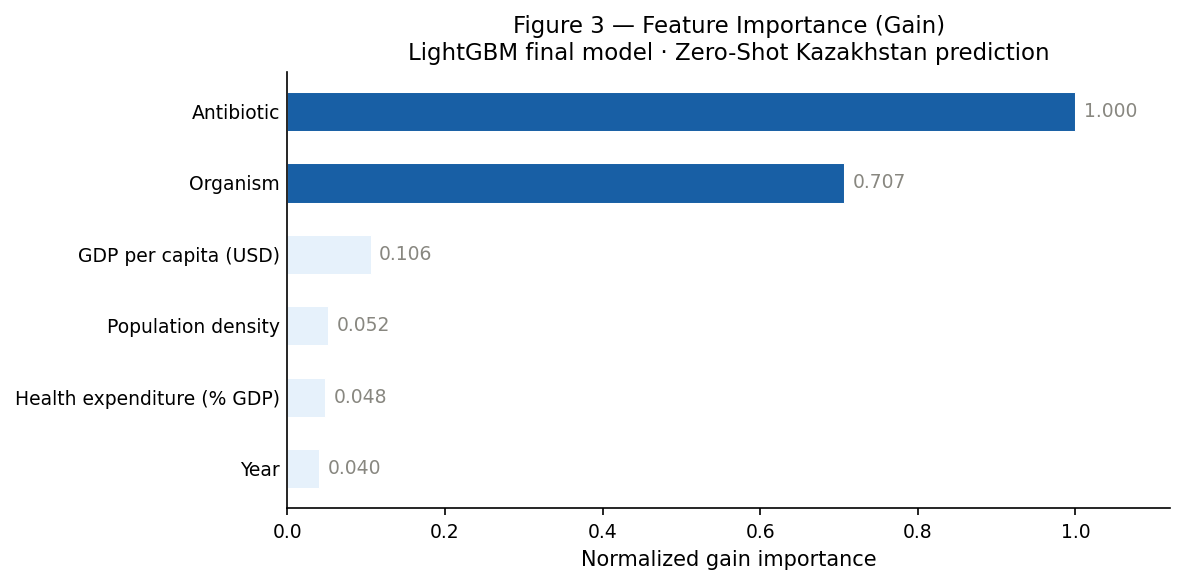

Saved: fig3_feature_importance.png


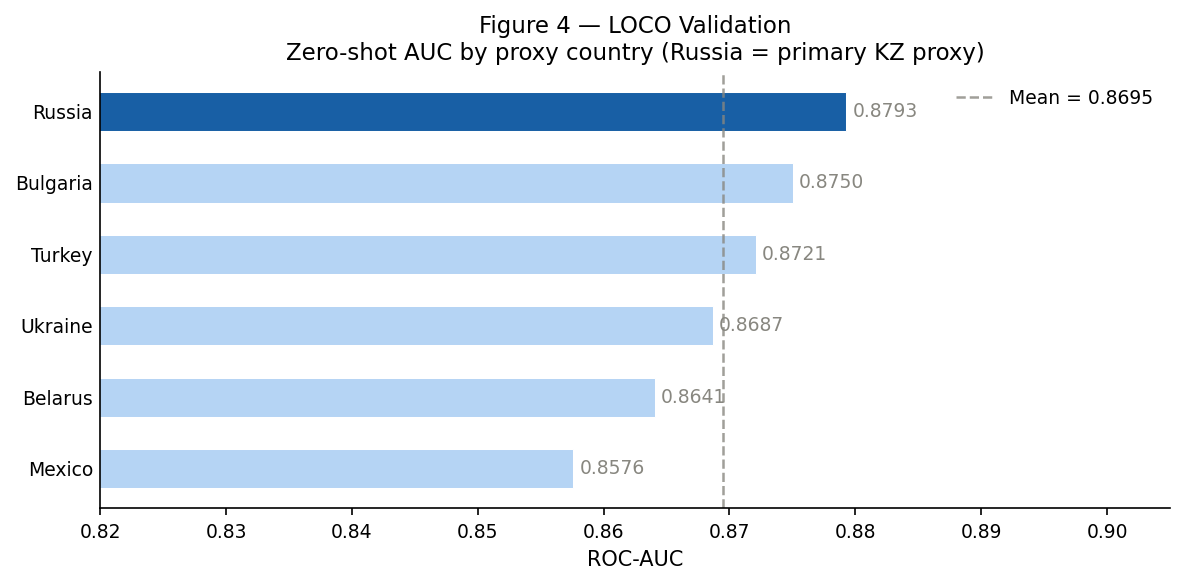

Saved: fig4_loco_validation.png


Text(0.5, 0, 'Fold (training window → validation window)')

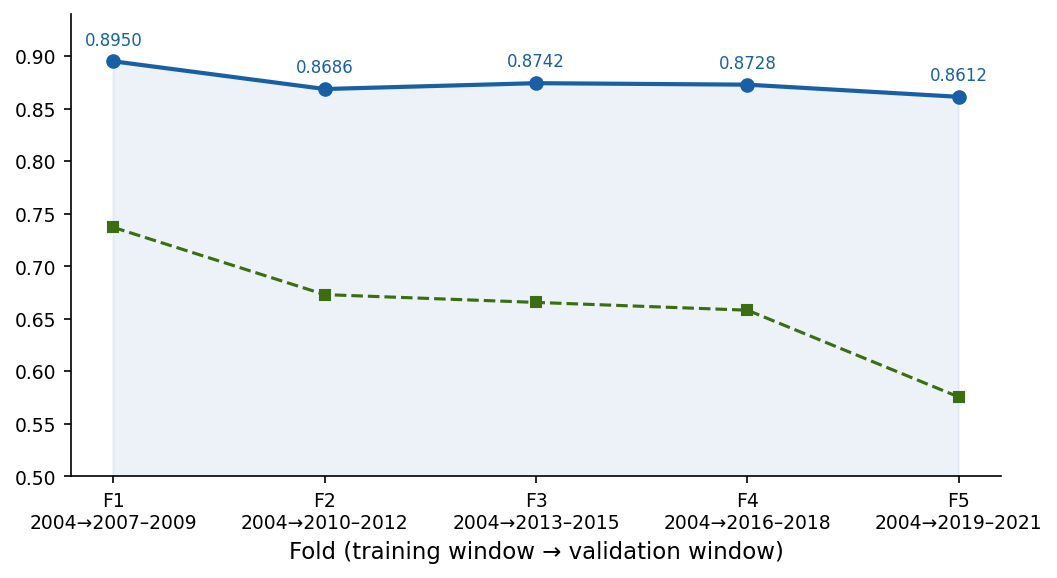

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
})

BLUE  = '#185FA5'
LBLUE = '#B5D4F4'
GREEN = '#3B6D11'
RED   = '#A32D2D'
LRED  = '#F09595'
GRAY  = '#888780'

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Figure 1 — Model Performance Comparison (Validation Set 2021–2022)',
             fontsize=11, y=1.02)

models = ['Random Forest', 'XGBoost', 'LightGBM']
aucs   = [roc_auc_score(y_val, y_pred_rf),
          roc_auc_score(y_val, y_pred_xgb),
          roc_auc_score(y_val, y_pred_lgb)]
auprcs = [average_precision_score(y_val, y_pred_rf),
          average_precision_score(y_val, y_pred_xgb),
          average_precision_score(y_val, y_pred_lgb)]
colors_bar = [LBLUE, LBLUE, BLUE]

for ax, vals, ylabel, baseline, title in zip(
    axes,
    [aucs, auprcs],
    ['ROC-AUC', 'AUPRC'],
    [0.5, 0.196],
    ['ROC-AUC', 'AUPRC']
):
    bars = ax.bar(models, vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1)
    ax.axhline(y=baseline, color=GRAY, linestyle='--', linewidth=1,
               label=f'Random baseline ({baseline:.3f})', alpha=0.7)
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(vals) - 0.08, max(vals) + 0.04)
    ax.legend(fontsize=8, frameon=False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='normal')
    ax.set_title(title)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('/kaggle/working/fig1_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig1_model_comparison.png")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_val, (y_pred_lgb > 0.5).astype(int),
    ax=ax, cmap='Blues',
    display_labels=['Susceptible', 'Resistant'],
    colorbar=False
)
ax.set_title('Figure 2 — Confusion Matrix\nLightGBM · Validation Set 2021–2022', pad=10)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

report = classification_report(y_val, (y_pred_lgb > 0.5).astype(int),
                                target_names=['Susceptible', 'Resistant'], digits=4)
print(report)
print("Saved: fig2_confusion_matrix.png")

feature_labels = {
    'antibiotic':                   'Antibiotic',
    'organism':                     'Organism',
    'gdp_per_capita_usd':           'GDP per capita (USD)',
    'population_density_per_sq_km': 'Population density',
    'health_expenditure_pct_gdp':   'Health expenditure (% GDP)',
    'year':                         'Year',
}
imp_vals = model_final.feature_importances_
imp_norm = imp_vals / imp_vals.max()
imp_df = pd.DataFrame({
    'feature': [feature_labels.get(f, f) for f in FEATURES],
    'importance': imp_norm
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_feat = [BLUE if v > 0.5 else LBLUE if v > 0.15 else '#E6F1FB' for v in imp_df['importance']]
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=colors_feat, edgecolor='white', linewidth=0.5, height=0.55)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, color=GRAY)
ax.set_xlim(0, 1.12)
ax.set_xlabel('Normalized gain importance')
ax.set_title('Figure 3 — Feature Importance (Gain)\nLightGBM final model · Zero-Shot Kazakhstan prediction')
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig3_feature_importance.png")

loco_sorted = loco_df.sort_values('AUC', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [BLUE if c == 'Russia' else LBLUE for c in loco_sorted['country']]
bars = ax.barh(loco_sorted['country'], loco_sorted['AUC'],
               color=bar_colors, edgecolor='white', linewidth=0.5, height=0.55)
ax.axvline(x=loco_df['AUC'].mean(), color=GRAY, linestyle='--', linewidth=1.2,
           label=f"Mean = {loco_df['AUC'].mean():.4f}", alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9, color=GRAY)
ax.set_xlim(0.82, 0.905)
ax.set_xlabel('ROC-AUC')
ax.set_title('Figure 4 — LOCO Validation\nZero-shot AUC by proxy country (Russia = primary KZ proxy)')
ax.legend(fontsize=9, frameon=False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_loco_validation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig4_loco_validation.png")

fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f"F{r['fold']}\n{r['train_years'].split('–')[0]}→{r['val_years']}"
               for _, r in cv_df.iterrows()]
ax.plot(fold_labels, cv_df['AUC'],   'o-', color=BLUE,  linewidth=2, markersize=6, label='AUC')
ax.plot(fold_labels, cv_df['AUPRC'], 's--', color=GREEN, linewidth=1.5, markersize=5, label='AUPRC')
ax.fill_between(fold_labels, cv_df['AUC'], alpha=0.08, color=BLUE)
for i, (_, row) in enumerate(cv_df.iterrows()):
    ax.annotate(f"{row['AUC']:.4f}", (i, row['AUC']), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color=BLUE)
ax.set_ylim(0.50, 0.94)
ax.set_xlabel('Fold (training window \u2192 validation window)', fontsize=11)